The goal here is to do a *single* forward model that could be compared to a single MSA exposure.  The intent here is to work out all the steps, get rough timing, and use that to determine which need further optimization.  All relevant notebooks start with `single_forward_model`.

This comes after the model spectrum was generated in [single_forward_model2_phmodel.ipynb](single_forward_model2_phmodel.ipynb)

In [1]:
import time
import pickle
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy import visualization as viz
viz.quantity_support()
from jwst import datamodels

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.interpolate import make_interp_spline
from tqdm.auto import tqdm

In [2]:
import os
os.environ['STPSF_PATH'] = os.path.expanduser('~/.cache/stpsf-data')

import stpsf

# Load Data and Information

In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

In [4]:
apogee_id = '2M19210086+3745339'
apogee_vhelio_avg = -45.42058
apogee_vunc = 0.1100559
apogee_teff = 4416.742
apogee_logg = 2.269546
apogee_m_h = 0.34755

apogee_feh = np.log10(apogee_m_h)

In [5]:
with open('single_forward_model_model_spec.pkl', 'rb') as f:
    data = pickle.load(f)

model_wave = data['wave']
model_flux = data['model']
model_path = data['phoenix_path']

# note that the normalization is at the "surface" of the star, so its crazy high - renormalize as needed
model_flux_fnu = model_flux.to(u.MJy, equivalencies=u.spectral_density(model_wave)) 

del data

# Determine PSF and wcs grid

Now we need to determine what PSF to use for this observation, and how it should be aligned in the image.

In [6]:
nrs = stpsf.setup_sim_to_match_file(str(n6791fits[0]))

Setting up sim to match ../ngc6791_cals/jw02609010001_03101_00001_nrs1_cal.fits


ValueError: The maximum allowed detector pixel coordinate value is (X,Y) = (2047, 2047)

The below is a  temporary stand-in...

In [7]:
nrs = stpsf.NIRSpec()
nrs.detector = dm0.meta.instrument.detector
nrs.filter = dm0.meta.instrument.filter
nrs.disperser = dm0.meta.instrument.grating

In [8]:
xdet, ydet = swcs.transform('detector', 'sca', *np.indices(slit.data.shape)[::-1])
nrs.detector_position = (np.mean(xdet), np.mean(ydet))

In [9]:
nrs.load_wss_opd_by_date(Time(dm0.meta.exposure.mid_time, format='mjd'))

iterating query, tdelta=3.0

MAST OPD query around UTC: 60136.5904089294
                        MJD: 60136.5904089294

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2023071203-NRCA3_FP1-1.fits
	Date (MJD):	 60136.5363
	Delta time:	 -0.0542 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/R2023071403-NRCA3_FP1-1.fits
	Date (MJD):	 60138.8979
	Delta time:	 2.3075 days
User requested choosing OPD time closest in time to 60136.5904089294, which is R2023071203-NRCA3_FP1-1.fits, delta time -0.054 days
Importing and format-converting OPD from /home/erik/.cache/stpsf-data/MAST_JWST_WSS_OPDs/R2023071203-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)


I *think* that the slit coordinate from the data file is in normalized slit coordinates (-0.5, 0.5) while stpsf expects arcsec offsets.

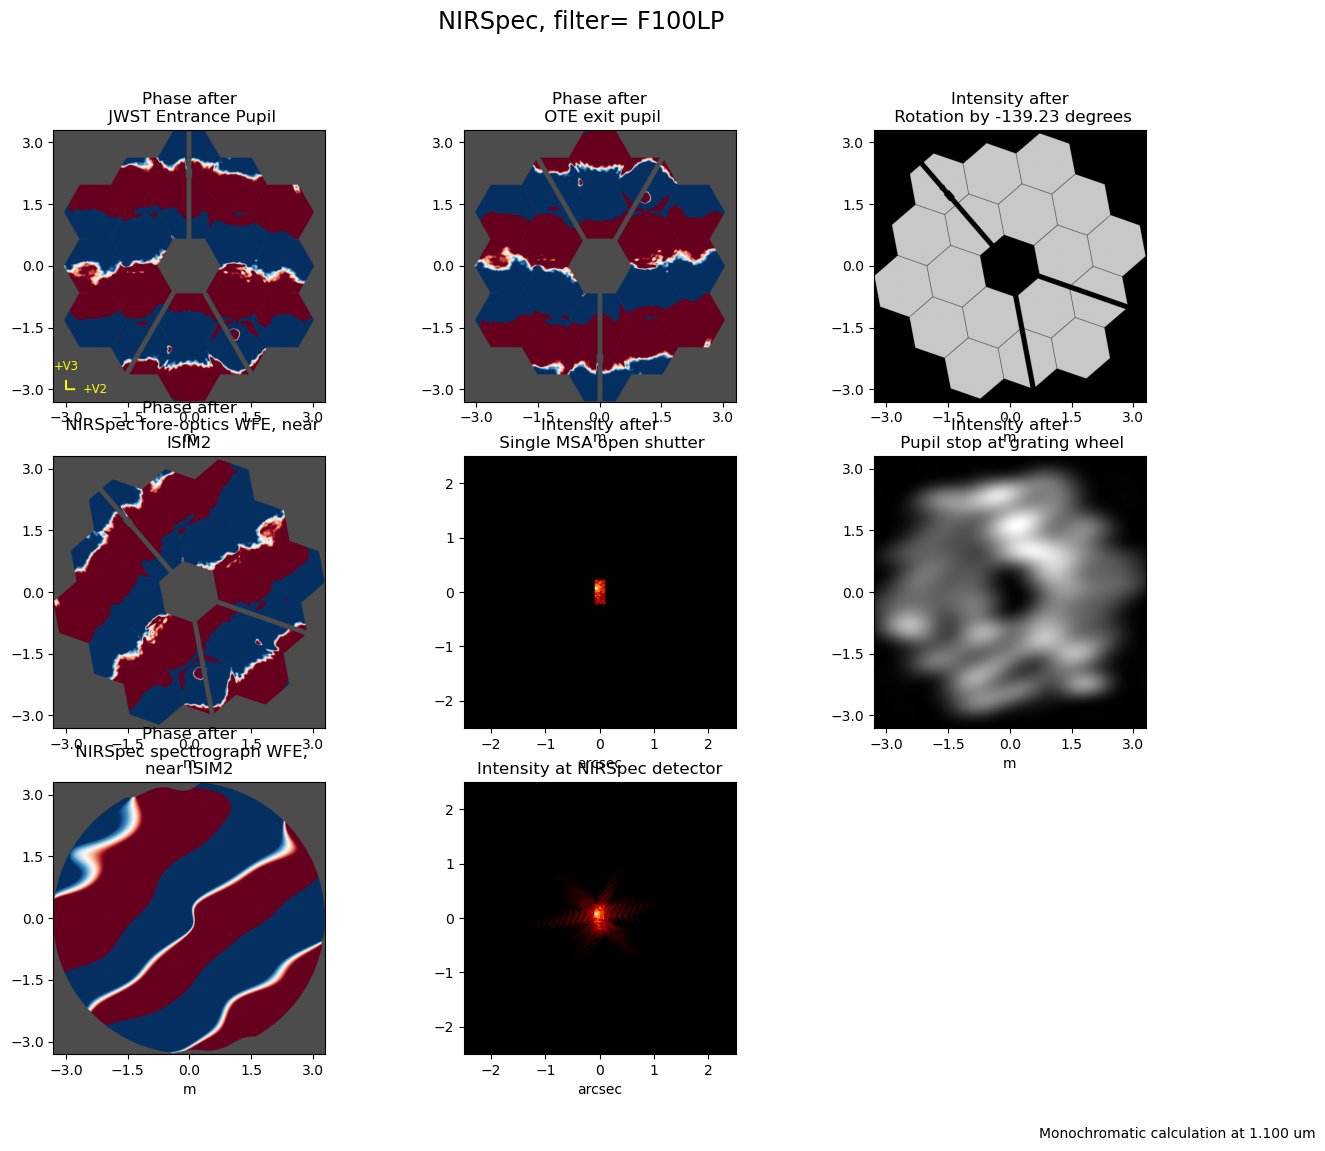

In [10]:
msa_slit_width = 0.2 #u.arcsec
msa_slit_height = 0.46 #u.arcsec

nrs.image_mask = 'Single MSA open shutter'
nrs.options.update({'source_offset_x': slit.source_xpos*msa_slit_width, 
                    'source_offset_y': slit.source_ypos*msa_slit_height})

plt.figure(figsize=(15, 12))
psf = nrs.calc_psf(monochromatic=1.1e-6, oversample=4, display=True)

((array([98]), array([93])), array([96., 96.]))

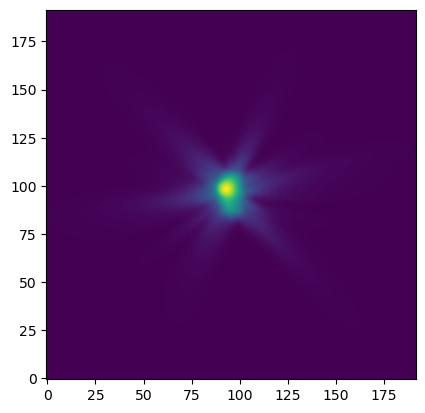

In [11]:
viz.imshow_norm(psf['OVERDIST'].data, origin='lower', interval=viz.MinMaxInterval(), stretch=viz.LogStretch(1e5))
np.where(psf['OVERDIST'].data == np.max(psf['OVERDIST'].data)), np.array(psf['OVERDIST'].data.shape)/2

Key point: the PSF is *no longer* centered in the image, but offset by the source coordinates. So to calculate the center offsets this needs to be taken into account.

First lets try to match the center without the off-centering:

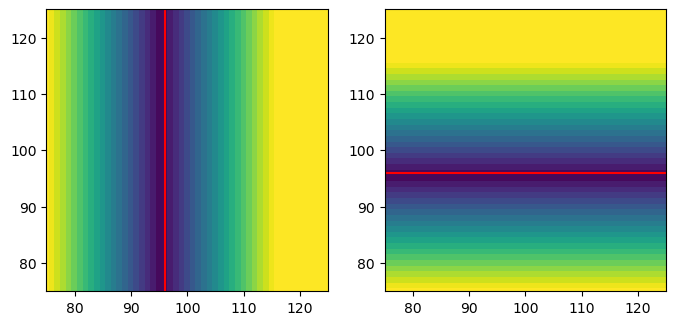

In [12]:
nrs.options.update({'source_offset_x': 0, 'source_offset_y': 0})
psf0 = nrs.calc_psf(monochromatic=1.1e-6, oversample=4, display=False)

offset_y, offset_x = np.indices(psf0['OVERDIST'].data.shape).astype(float)
offset_x -= np.max(offset_x)/2
offset_y -= np.max(offset_y)/2

offset_x /= psf0['OVERDIST'].header['DET_SAMP']
offset_y /= psf0['OVERDIST'].header['DET_SAMP']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 12))

ax1.imshow(np.abs(offset_x), vmin=0, vmax=5)
ax1.axvline(np.where(psf0['OVERDIST'].data == np.max(psf0['OVERDIST'].data))[1], color='r')

ax2.imshow(np.abs(offset_y), vmin=0, vmax=5)
ax2.axhline(np.where(psf0['OVERDIST'].data == np.max(psf0['OVERDIST'].data))[0], color='r')

for ax in (ax1, ax2):
    ax.set_xlim(75, 125)
    ax.set_ylim(75, 125)

Ok that seems right to within a pixel which is the best we can expect. Now with and without correction for the source mis-centering:

Text(0.5, 1.0, 'uncorrected')

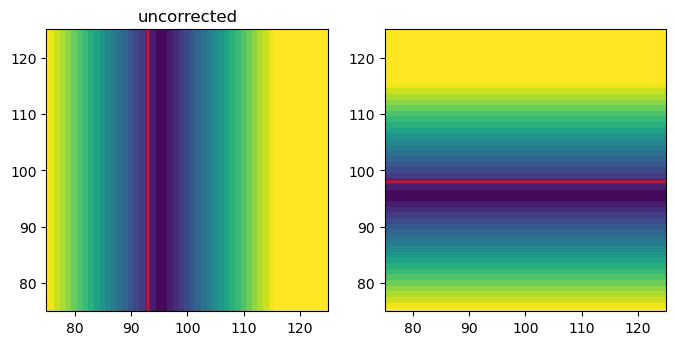

In [13]:
offset_y, offset_x = np.indices(psf['OVERDIST'].data.shape).astype(float)
offset_x -= np.max(offset_x)/2
offset_y -= np.max(offset_y)/2

offset_x /= psf['OVERDIST'].header['DET_SAMP']
offset_y /= psf['OVERDIST'].header['DET_SAMP']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 12))

ax1.imshow(np.abs(offset_x), vmin=0, vmax=5)
ax1.axvline(np.where(psf['OVERDIST'].data == np.max(psf['OVERDIST'].data))[1], color='r')

ax2.imshow(np.abs(offset_y), vmin=0, vmax=5)
ax2.axhline(np.where(psf['OVERDIST'].data == np.max(psf['OVERDIST'].data))[0], color='r')

for ax in (ax1, ax2):
    ax.set_xlim(75, 125)
    ax.set_ylim(75, 125)

ax1.set_title('uncorrected')

Text(0.5, 1.0, 'corrected')

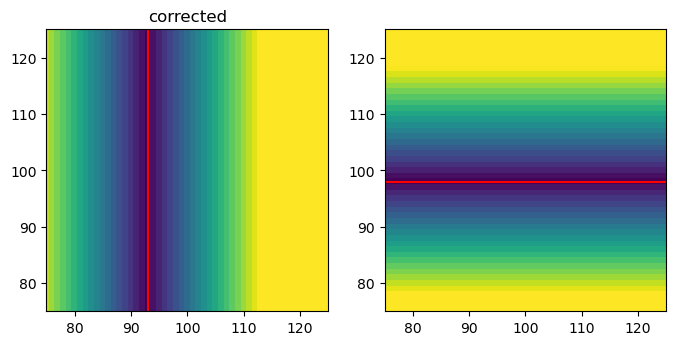

In [14]:
offset_y, offset_x = np.indices(psf['OVERDIST'].data.shape).astype(float)
offset_x -= np.max(offset_x)/2
offset_y -= np.max(offset_y)/2

offset_x -= slit.source_xpos*msa_slit_width/psf['OVERDIST'].header['PIXELSCL']
offset_y -= slit.source_ypos*msa_slit_height/psf['OVERDIST'].header['PIXELSCL']

offset_x /= psf['OVERDIST'].header['DET_SAMP']
offset_y /= psf['OVERDIST'].header['DET_SAMP']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 12))

ax1.imshow(np.abs(offset_x), vmin=0, vmax=5)
ax1.axvline(np.where(psf['OVERDIST'].data == np.max(psf['OVERDIST'].data))[1], color='r')

ax2.imshow(np.abs(offset_y), vmin=0, vmax=5)
ax2.axhline(np.where(psf['OVERDIST'].data == np.max(psf['OVERDIST'].data))[0], color='r')

for ax in (ax1, ax2):
    ax.set_xlim(75, 125)
    ax.set_ylim(75, 125)

ax1.set_title('corrected')

# Build multi-wavelength interpolatable PSF

See [stpsf_tests.ipynb](stpsf_tests.ipynb) - this shows the wavelength variation is quite small and possibly ignorable, but we show how it might be done below in case the performance penalty isn't too terrible.

In [15]:
wl_grid_size = 3

datasky, dataspec = swcs.pixel_to_world(*np.indices(slit.data.shape)[::-1])
psf_wl_grid = np.linspace(np.nanmin(dataspec), np.nanmax(dataspec), wl_grid_size)

minpx = np.where(np.nanmin(dataspec) == dataspec)
cenpx = np.where(np.nanmin(np.abs(psf_wl_grid[1] - dataspec)) == np.abs(psf_wl_grid[1] - dataspec))
maxpx = np.where(np.nanmax(dataspec) == dataspec)

psf_grid_pixels = [minpx, cenpx, maxpx]

In [16]:
oversampling_factor = 4
nrs.options.update({'source_offset_x': slit.source_xpos*msa_slit_width, 'source_offset_y': slit.source_ypos*msa_slit_height})

psfs = []
for wl, pxs in tqdm(zip(psf_wl_grid, psf_grid_pixels)):
    ypxs, xpxs = pxs
    nrs.detector_position = swcs.transform('detector', 'sca', xpxs[0], ypxs[0])
    print(xpxs[0], ypxs[0], swcs.transform('detector', 'sca', xpxs[0], ypxs[0]))
    psfs.append(nrs.calc_psf(monochromatic=wl.to(u.m).value, oversample=oversampling_factor, display=False))

0it [00:00, ?it/s]

0 28 (325.0, 472.0)


/home/erik/astro/m31_jwst_2609_vol2/.pixi/envs/default/lib/python3.14/site-packages/stpsf/utils.py:920: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  ind_i_let = re.search('\w',


ValueError: Given V2V3 coordinates [ 3.36117903 -8.45991402] arcmin do not fall within an instrument FOV region

WARNING: this might imply something is wrong with the psf math... but lets do a quicker-and-dirtier version

In [17]:
wl_grid_size = 3

datasky, dataspec = swcs.pixel_to_world(*np.indices(slit.data.shape)[::-1])
psf_wl_grid = np.linspace(np.nanmin(dataspec), np.nanmax(dataspec), wl_grid_size+2)[1:-1]

oversampling_factor = 4
nrs.options.update({'source_offset_x': slit.source_xpos*msa_slit_width, 'source_offset_y': slit.source_ypos*msa_slit_height})

psfs = []
for wl in tqdm(psf_wl_grid):
    nrs.detector_position = swcs.transform('detector', 'sca', *swcs.world_to_pixel(scoord, wl))
    psfs.append(nrs.calc_psf(monochromatic=wl.to(u.m).value, oversample=oversampling_factor, display=False))

  0%|          | 0/3 [00:00<?, ?it/s]

In [18]:
wl_grid_size = 3

datasky, dataspec = swcs.pixel_to_world(*np.indices(slit.data.shape)[::-1])
psf_wl_grid = np.linspace(np.nanmin(dataspec), np.nanmax(dataspec), wl_grid_size+2)[1:-1]

oversampling_factor = 4
nrs.options.update({'source_offset_x': slit.source_xpos*msa_slit_width, 'source_offset_y': slit.source_ypos*msa_slit_height})

nrs.detector_position = stpsf.NIRSpec().detector_position # back to default

psfs_nodet = []
for wl in tqdm(psf_wl_grid):
    psfs_nodet.append(nrs.calc_psf(monochromatic=wl.to(u.m).value, oversample=oversampling_factor, display=False))

  0%|          | 0/3 [00:00<?, ?it/s]

Alright compare the detector to the wavelength effects

per pixel mean percent error -0.1691519000757025
mean total flux error 0.003192116441517401


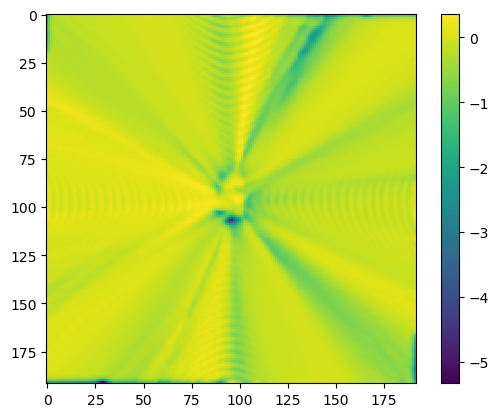

In [19]:
plt.imshow(1 - psfs[0]['OVERDIST'].data/psfs_nodet[0]['OVERDIST'].data, interpolation='nearest')
plt.colorbar()
print('per pixel mean percent error', np.mean(1 - psfs[0]['OVERDIST'].data/psfs_nodet[0]['OVERDIST'].data))
print('mean total flux error', 1 - np.mean(psfs[0]['OVERDIST'].data)/np.mean(psfs_nodet[0]['OVERDIST'].data))

per pixel mean percent error 0.13180381930701254
mean total flux error 0.014570358446008846


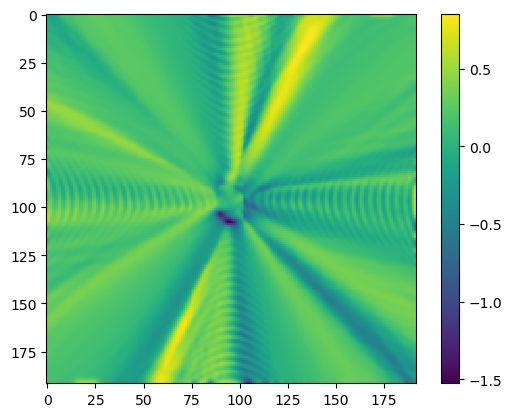

In [20]:
plt.imshow(1 - psfs[0]['OVERDIST'].data/psfs[1]['OVERDIST'].data, interpolation='nearest')
plt.colorbar()
print('per pixel mean percent error', np.mean(1 - psfs[0]['OVERDIST'].data/psfs[1]['OVERDIST'].data))
print('mean total flux error', 1 - np.mean(psfs[0]['OVERDIST'].data)/np.mean(psfs[1]['OVERDIST'].data))

So both effects matter a fair amount at a per pixel level, but the wavelength is way more important in a total flux sense, so lets proceed since that seems more likely to be right.

0.00040793418884277344

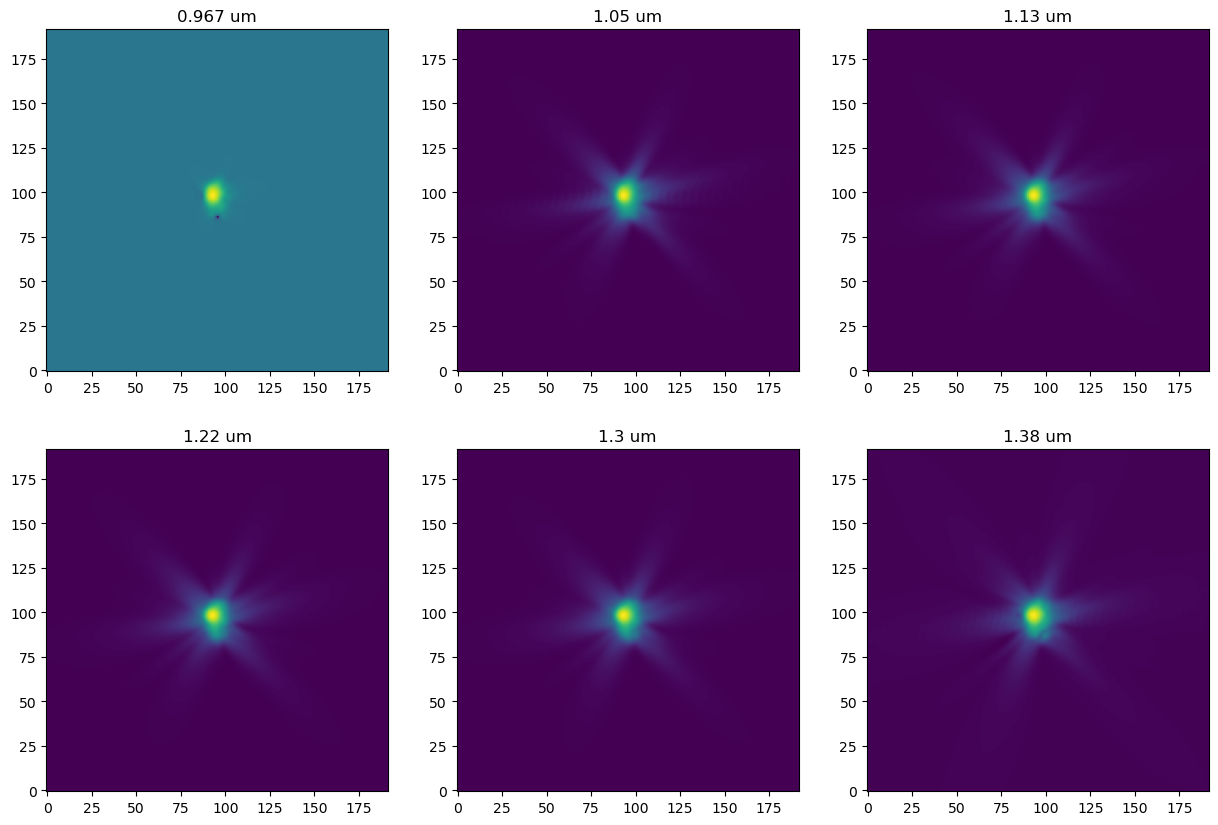

In [21]:
psf_grid = make_interp_spline(psf_wl_grid.value, np.array([p['OVERDIST'].data for p in psfs]), k=2)


test_wls = np.linspace(np.nanmin(dataspec), np.nanmax(dataspec), 6)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for ax, wl in zip(axs.ravel(), test_wls):
    psf_interp = psf_grid(wl)
    viz.imshow_norm(psf_interp, origin='lower', interval=viz.MinMaxInterval(), stretch=viz.LogStretch(1e5), ax=ax)
    ax.set_title(f'{wl:.3}')


st = time.time()
for wl in test_wls:
    psf_interp = psf_grid(wl)
et = time.time()


et-st

Even on CPU this is less than a ms so no issues there.

After working out the above, got some information from instrument/telescope folks that probably the detector position dependence on nirspec is not that important big picture, so will only go back and worry about this if it seems like the fitting residuals show enough signs of psf variation to care about this further. So just use the center-detector solution for now.

In [22]:
nrs.detector_position = stpsf.NIRSpec().detector_position # back to default

Make sure we know how to get equivalent fovs

In [23]:
res = nrs.calc_psf(monochromatic=wl.to(u.m).value, oversample=4, display=False)
res.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  OVERSAMP      1 PrimaryHDU     114   (192, 192)   float64   
  1  DET_SAMP      1 ImageHDU       116   (48, 48)   float64   
  2  OVERDIST      1 ImageHDU       163   (192, 192)   float64   
  3  DET_DIST      1 ImageHDU       164   (48, 48)   float64   


In [24]:
res = nrs.calc_psf(monochromatic=wl.to(u.m).value, oversample=4, display=False, fov_pixels=48)
res.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  OVERSAMP      1 PrimaryHDU     114   (192, 192)   float64   
  1  DET_SAMP      1 ImageHDU       116   (48, 48)   float64   
  2  OVERDIST      1 ImageHDU       163   (192, 192)   float64   
  3  DET_DIST      1 ImageHDU       164   (48, 48)   float64   


  0%|          | 0/3 [00:00<?, ?it/s]

((180, 180),
 (20, 20),
 np.float64(0.7406144608629258),
 np.float64(0.7406144608629259))

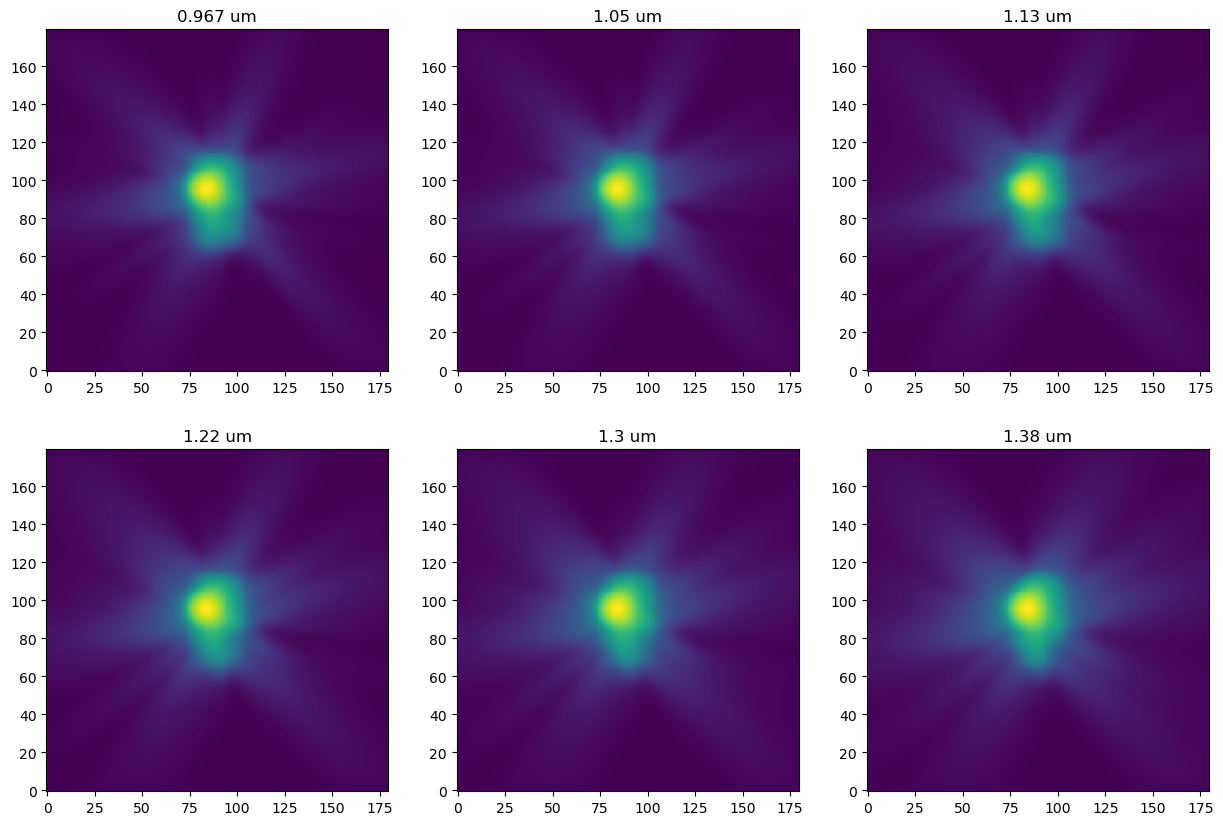

In [25]:
wl_grid_size = 3
oversampling_factor = 9
fovpx = 20

datasky, dataspec = swcs.pixel_to_world(*np.indices(slit.data.shape)[::-1])
psf_wl_grid = np.linspace(np.nanmin(dataspec), np.nanmax(dataspec), wl_grid_size)

nrs.options.update({'source_offset_x': slit.source_xpos*msa_slit_width, 'source_offset_y': slit.source_ypos*msa_slit_height})

nrs.detector_position = stpsf.NIRSpec().detector_position # back to default

psfs = []
for wl in tqdm(psf_wl_grid):
    psf = nrs.calc_psf(monochromatic=wl.to(u.m).value, oversample=oversampling_factor, fov_pixels=fovpx, display=False)
    psfs.append(psf)

psf_grid = make_interp_spline(psf_wl_grid.value, np.array([p['OVERDIST'].data for p in psfs]), k=2)


test_wls = np.linspace(np.nanmin(dataspec), np.nanmax(dataspec), 6)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for ax, wl in zip(axs.ravel(), test_wls):
    psf_interp = psf_grid(wl)
    viz.imshow_norm(psf_interp, origin='lower', interval=viz.MinMaxInterval(), stretch=viz.LogStretch(1e5), ax=ax, interpolation='nearest')
    ax.set_title(f'{wl:.3}')

for wl in test_wls:
    psf_interp = psf_grid(wl)

psfs[0]['OVERSAMP'].data.shape, psfs[0]['DET_SAMP'].data.shape, np.sum(psfs[0]['OVERSAMP'].data), np.sum(psfs[0]['DET_SAMP'].data)

update the offsets for the last PSF

In [ ]:
offset_y, offset_x = np.indices(psf['OVERDIST'].data.shape).astype(float)
offset_x -= np.max(offset_x)/2
offset_y -= np.max(offset_y)/2


offset_x -= slit.source_xpos*msa_slit_width/psf['OVERDIST'].header['PIXELSCL']
offset_y -= slit.source_ypos*msa_slit_height/psf['OVERDIST'].header['PIXELSCL']

offset_x /= psf['OVERDIST'].header['DET_SAMP']
offset_y /= psf['OVERDIST'].header['DET_SAMP']

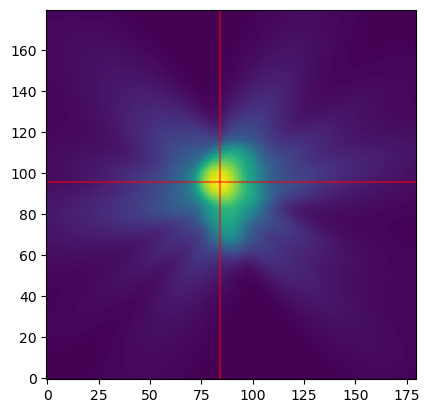

In [85]:
centerx = slit.source_xpos*msa_slit_width/psf['OVERDIST'].header['PIXELSCL'] + (psf['OVERDIST'].shape[1]-1)/2
centery = slit.source_ypos*msa_slit_height/psf['OVERDIST'].header['PIXELSCL'] + (psf['OVERDIST'].shape[0]-1)/2

viz.imshow_norm(psf['OVERDIST'].data, origin='lower', interval=viz.MinMaxInterval(), stretch=viz.LogStretch(1e5), interpolation='nearest')
plt.axhline(centery, alpha=.5,c='r')
plt.axvline(centerx, alpha=.5,c='r')

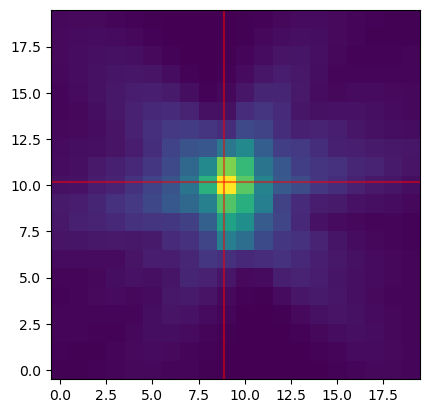

In [86]:
centerx_det = slit.source_xpos*msa_slit_width/psf['DET_SAMP'].header['PIXELSCL'] + (psf['DET_SAMP'].shape[1]-1)/2
centery_det = slit.source_ypos*msa_slit_height/psf['DET_SAMP'].header['PIXELSCL'] + (psf['DET_SAMP'].shape[0]-1)/2

viz.imshow_norm(psf['DET_SAMP'].data, origin='lower', interval=viz.MinMaxInterval(), stretch=viz.LogStretch(1e5), interpolation='nearest')
plt.axhline(centery_det, alpha=.5,c='r')
plt.axvline(centerx_det, alpha=.5,c='r')

Save it out for use later

In [87]:
with open(f'single_forward_model_psf_grid_os{oversampling_factor}_fov{fovpx}.pkl', 'wb') as f:
    pickle.dump({'psf_grid': psf_grid, 'psf_wl_grid': psf_wl_grid, 
                 'psf_source_offset_x_px': offset_x, 'psf_source_offset_y_px': offset_y, 
                 'psf_source_offset_x_asec': psf['OVERDIST'].header['PIXELSCL']*offset_x * u.arcsec, 
                 'psf_source_offset_y_asec': psf['OVERDIST'].header['PIXELSCL']*offset_y * u.arcsec,
                 'oversampling_factor': oversampling_factor, 'fov_pixels': fovpx,
                 'center_x_os': centerx, 'center_y_os': centery,
                 'center_x_det': centerx_det, 'center_y_det': centery_det,
                 }, f)